# Метод главных компонент

Сократим число признаков через PCA, сохранив не менее 95% объяснённой дисперсии, и проверим качество классификации.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Matplotlib is building the font cache; this may take a moment.


In [2]:
features, target = load_wine(return_X_y=True, as_frame=True)
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])
pipeline.fit(train_features, train_target)
prediction = pipeline.predict(test_features)

In [3]:
pca = pipeline.named_steps["pca"]
pd.Series({
    "source_features": features.shape[1],
    "selected_components": pca.n_components_,
    "explained_variance": pca.explained_variance_ratio_.sum(),
    "accuracy": accuracy_score(test_target, prediction),
}).to_frame("value")

,value
source_features,13.000000
selected_components,10.000000
explained_variance,0.963720
accuracy,0.977778


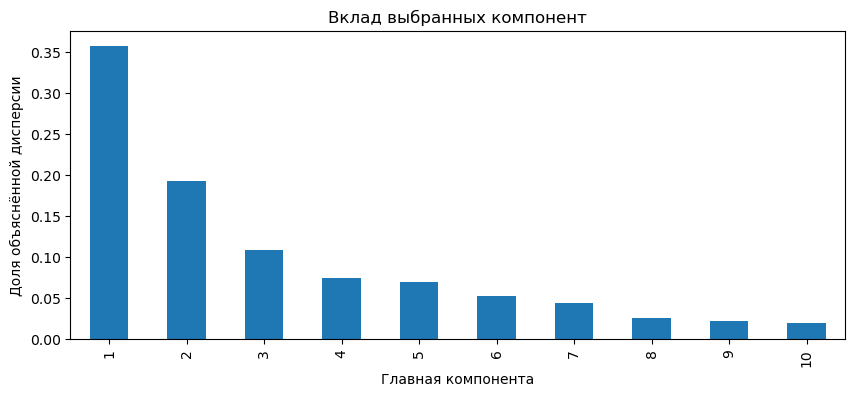

In [4]:
pd.Series(pca.explained_variance_ratio_, index=range(1, pca.n_components_ + 1)).plot.bar(figsize=(10, 4))
plt.xlabel("Главная компонента")
plt.ylabel("Доля объяснённой дисперсии")
plt.title("Вклад выбранных компонент")
plt.show()